## 🧠 YOLO-MultiSpectral: Demo Notebook UNDER CONSTRUCTION (1/7/2025)

### 🔍 Section 1: Introduction

This notebook demonstrates how to modify a YOLO model 5 channel input.
Dataset weeds galore


---

### ⚙️ Step 1: Setup Environment

Below we install dependencies and clone the YOLO-MultiSpec repository.


In [ ]:

#  Clone repository and install requirements.txt
import os
import shutil
import subprocess

current_path = os.getcwd()
clone_dir = current_path + "/YOLO-Multispectral"
# Update if exists
if os.path.isdir(clone_dir):
    print(f"🧹Update any change files {clone_dir}")
    %cd {clone_dir}
    # !git fetch origin
    # !git reset --hard origin/main
    # !git clean -fd

    !git pull
    #%cd ..  # return to original directory if needed
else:
    # Clone your GitHub repo
    !git clone https://github.com/aesparon/YOLO-Multispectral.git
    # Change directory to the repo root   REMOVE FOR COLAB
    %cd YOLO-Multispectral

# Now install requirements
req_path = os.path.join(clone_dir, "code", "requirements.txt")
!pip install -r "{req_path}"



### 🔍 Step 2. download weeds galore dataset

Download dataset

In [3]:
# add code path for script files
import os
import sys 
# add code folder
yolo_source_path = os.path.abspath(clone_dir +  "/code/")
sys.path.insert(0, yolo_source_path)
from utils_downloader import download_and_extract_zip

# Set parameters
url = "https://doidata.gfz.de/weedsgalore_e_celikkan_2024/weedsgalore-dataset.zip"
output_zip = clone_dir + "/datasets/weedsgalore-dataset.zip"
extract_dir = clone_dir + "/datasets/"

# Call the function
download_and_extract_zip(url, output_zip, extract_dir)

🔍 Checking file info...
✅ File already fully downloaded.
📦 Extracting...


Extracting: 100%|██████████| 1119/1119 [00:01<00:00, 833.99file/s]

✅ Extracted to: d:\PD\Publications\Yolo_mod\github\colab_test\notebooks/YOLO-Multispectral/datasets/


### 🔍 Section 3: Create train/val/test for RGB and RGBRN


In [ ]:
from pre_process_images import *

clip_size= "600"
classes_list = ['maize','amaranth','grass','quickweed','other']
number_of_classes = len(classes_list)

# Step 1.  Merge all date folder images into single folder  ###########################################################
input_folders = [
    extract_dir + "/weedsgalore-dataset/2023-05-25/images/",
    extract_dir + "/weedsgalore-dataset/2023-05-30/images/",
    extract_dir + "/weedsgalore-dataset/2023-06-06/images/",
    extract_dir + "/weedsgalore-dataset/2023-06-15/images/"
]
images_merge_band_images = extract_dir + "/weedsgalore-dataset/images_merge/"

# merge all band images from all date folders into a single folder
merge_files(input_folders, images_merge_band_images)

# Step 2.  Stack RGB and RGBRN images and convert from uint16 to uint8 and split train/val/test  #######################################################3
#data_type = 'uint8'    # 'uint16'     #  yolo does not train on uint16 but will mod yolo to test any increase in accuracy using uinr16 over uint8 (future wotk)
uint16_to_uint8_method = 'stretch'    # 'normalize' 

#################################################     RGB   #############################################################
# stack RGB and convert to uint8 and separate to train/val/test using same split as weeds-galore
labels_path_to_merge_RGB =  clone_dir + '/datasets/weeds_galore_processed/RGB/'
output_RGB_train_val_test_path = stack_RGB_set_uint8_sort_train_val_test (images_merge_band_images , uint16_to_uint8_method, labels_path_to_merge_RGB )
project_base_path_RGB =  output_RGB_train_val_test_path + '/outputs/'      #  'D:/PD/yolo_mod/working2/projects/weeds_galore/RGBRN_tests_final2/'
os.makedirs(project_base_path_RGB, exist_ok=True)
# can auto detect
number_of_channels_RGB = 3 
# expect folders for images/labels in train/val/test
images_train_path_RGB= output_RGB_train_val_test_path +  "train/" 
images_val_path_RGB=  output_RGB_train_val_test_path + "val/" 
# set to '' or None id NO test data for datasets with no test data
images_test_path_RGB =  output_RGB_train_val_test_path + "test/" 



#################################################     RGBRN   #############################################################
#stack RGBRN and convert to uint8 and separate to train/val/test using same split as weeds-galore
labels_path_to_merge_RGBRN =  clone_dir + '/datasets/weeds_galore_processed/RGBRN/'
output_RGBRN_train_val_test_path =  stack_RGBRN_set_uint8_sort_train_val_test (images_merge_band_images , uint16_to_uint8_method , labels_path_to_merge_RGBRN  )
project_base_path_RGBRN =  output_RGBRN_train_val_test_path + '/outputs/'      #  'D:/PD/yolo_mod/working2/projects/weeds_galore/RGBRN_tests_final2/'
os.makedirs(project_base_path_RGBRN, exist_ok=True)
# can auto detect
number_of_channels_RGBRN = 5  
# expect folders for images/labels in train/val/test
images_train_path_RGBRN= output_RGBRN_train_val_test_path +  "train/" 
images_val_path_RGBRN=  output_RGBRN_train_val_test_path + "val/" 
# set to '' or None id NO test data for datasets with no test data
images_test_path_RGBRN=  output_RGBRN_train_val_test_path + "test/"    




✅ Copied: d:\PD\Publications\Yolo_mod\github\colab_test\notebooks/YOLO-Multispectral/datasets//weedsgalore-dataset/2023-05-25/images/2023-05-25_0109_B.png → d:\PD\Publications\Yolo_mod\github\colab_test\notebooks/YOLO-Multispectral/datasets//weedsgalore-dataset/images_merge/2023-05-25_0109_B_4.png
✅ Copied: d:\PD\Publications\Yolo_mod\github\colab_test\notebooks/YOLO-Multispectral/datasets//weedsgalore-dataset/2023-05-25/images/2023-05-25_0109_G.png → d:\PD\Publications\Yolo_mod\github\colab_test\notebooks/YOLO-Multispectral/datasets//weedsgalore-dataset/images_merge/2023-05-25_0109_G_4.png
✅ Copied: d:\PD\Publications\Yolo_mod\github\colab_test\notebooks/YOLO-Multispectral/datasets//weedsgalore-dataset/2023-05-25/images/2023-05-25_0109_NIR.png → d:\PD\Publications\Yolo_mod\github\colab_test\notebooks/YOLO-Multispectral/datasets//weedsgalore-dataset/images_merge/2023-05-25_0109_NIR_4.png
✅ Copied: d:\PD\Publications\Yolo_mod\github\colab_test\notebooks/YOLO-Multispectral/datasets//weed

c:\Users\andre\.conda\envs\yolo-ms3\lib\site-packages\rasterio\__init__.py:368: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
c:\Users\andre\.conda\envs\yolo-ms3\lib\site-packages\rasterio\__init__.py:378: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(


✅ Saved: d:\PD\Publications\Yolo_mod\github\colab_test\notebooks/YOLO-Multispectral/datasets/weeds_galore_processed/RGB//RGB_uint16/2023-05-25_0170.tif
✅ Saved: d:\PD\Publications\Yolo_mod\github\colab_test\notebooks/YOLO-Multispectral/datasets/weeds_galore_processed/RGB//RGB_uint16/2023-05-25_0183.tif
✅ Saved: d:\PD\Publications\Yolo_mod\github\colab_test\notebooks/YOLO-Multispectral/datasets/weeds_galore_processed/RGB//RGB_uint16/2023-05-25_0189.tif
✅ Saved: d:\PD\Publications\Yolo_mod\github\colab_test\notebooks/YOLO-Multispectral/datasets/weeds_galore_processed/RGB//RGB_uint16/2023-05-25_0219.tif
✅ Saved: d:\PD\Publications\Yolo_mod\github\colab_test\notebooks/YOLO-Multispectral/datasets/weeds_galore_processed/RGB//RGB_uint16/2023-05-25_0222.tif
✅ Saved: d:\PD\Publications\Yolo_mod\github\colab_test\notebooks/YOLO-Multispectral/datasets/weeds_galore_processed/RGB//RGB_uint16/2023-05-25_0228.tif
✅ Saved: d:\PD\Publications\Yolo_mod\github\colab_test\notebooks/YOLO-Multispectral/data

# Visualise annoatations

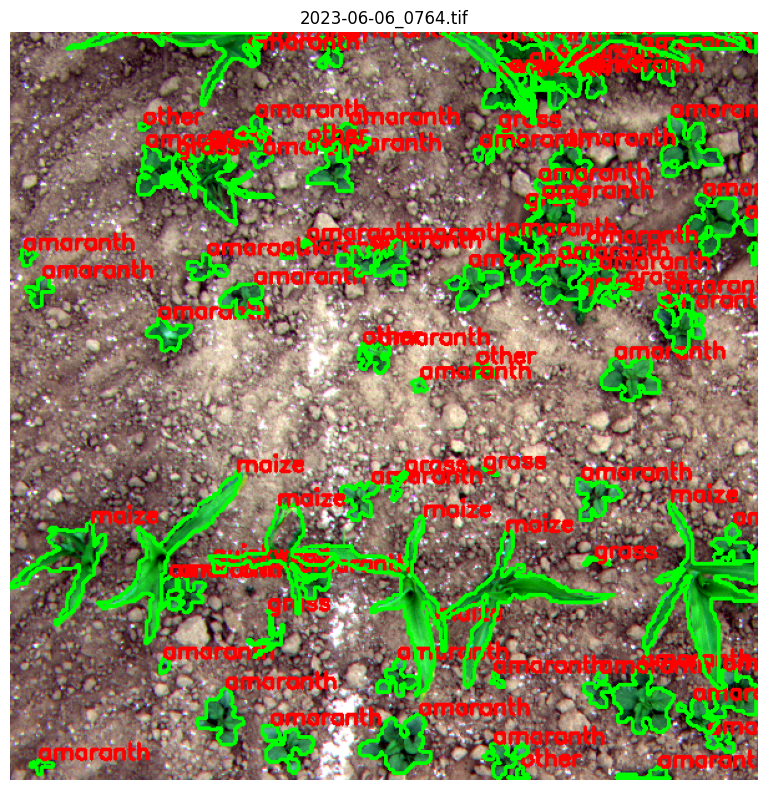

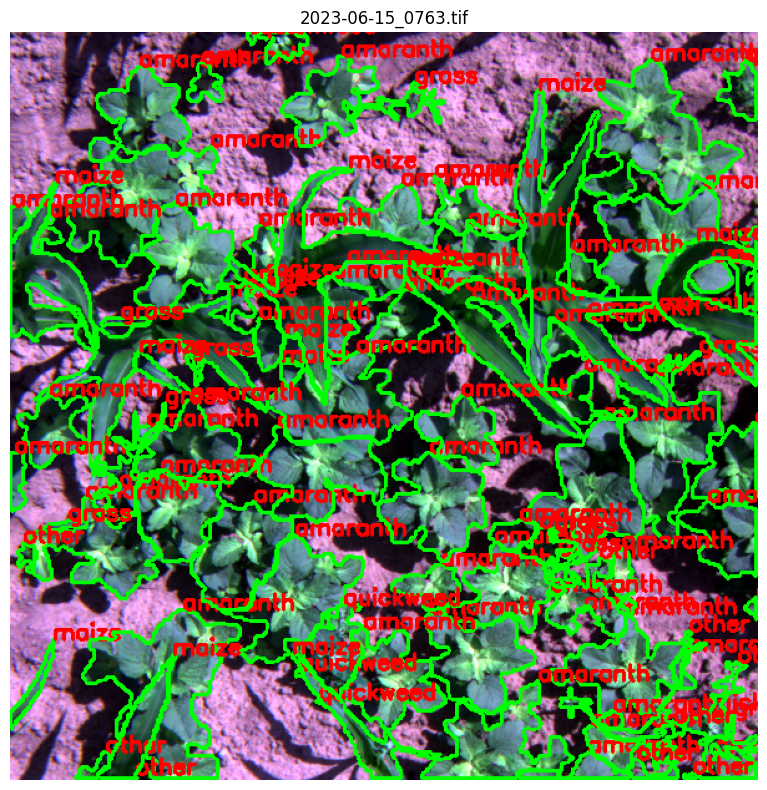

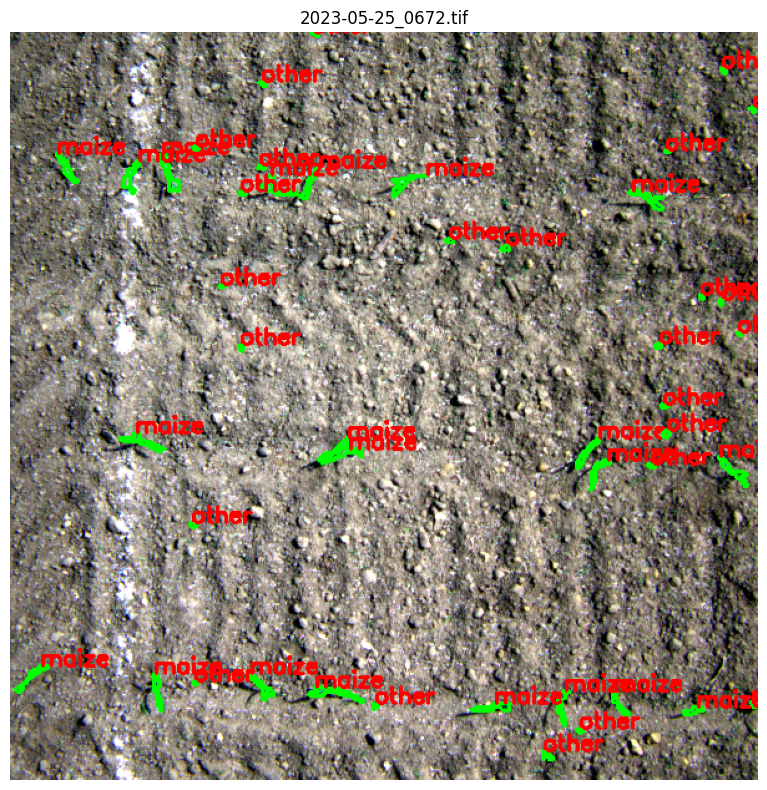

In [21]:
import importlib
import visualise_yolo_annotations

importlib.reload(visualise_yolo_annotations)
from visualise_yolo_annotations import plot_yolo_segmentation
%matplotlib inline

num_samples = 3
plot_yolo_segmentation(images_train_path_RGB + '/images/', images_train_path_RGB + '/labels/', class_names=classes_list, num_samples=num_samples)

### Custom YOLO model parameters for multispectral modification

In [ ]:
from pathlib import Path
from mod_pt_model_seg import patch_yolo_seg_ckpt
from train_eval import create_train_yaml


# add hic fix - test and fix - then remove
#os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# yolo modified model configuration
model_base =  'yolov8x-seg.pt'    #   'yolo11x-seg.yaml'    # 'yolo11n-seg.pt'
#folder = model_base[0:6]
#Initialise additional channels when more then 3 (RGB)
channel_init_mode =  'avg'          #  'random'       # 'avg'   'zeros'     'random'    'same'
# trans_learn = True     # False      # True       #False    #True

use_cbam=False
use_eca=False
use_spectral=False 
use_dropblock=False
drop_prob=0.1


model_base_str = model_base.replace('.','_') # for file path - remove .extension


#################################################     RGB mod yolo model      ###########################################################################
output_model_train_base_RGB =  project_base_path_RGB  + '_RGB_' + model_base_str + '_method_add_ch_' + channel_init_mode 
#os.makedirs(output_model_train_base, exist_ok=True)

# from mod_pt_model_seg_v1.py
model_created_RGB ,output_model_train_RGB  = patch_yolo_seg_ckpt (
    #input_ckpt='C:/Users/andre/AppData/Roaming/QGIS/QGIS3/profiles/default/python/plugins/aigist/QGIS_DL/models_base/YOLO8/yolo11x-seg.pt',
    model_base=model_base,
    output_model_train= output_model_train_base_RGB,
    yolo_source_path = yolo_source_path,
    in_channels=number_of_channels_RGB,
    nc=number_of_classes,
    #trans_learn = trans_learn,
    channel_init_mode=channel_init_mode,
    use_cbam=use_cbam, 
    use_eca=use_eca, 
    use_spectral=use_spectral, 
    use_dropblock=use_dropblock, 
    drop_prob=0.1
)
# dynamic create train yaml
output_yaml_RGB =  project_base_path_RGB + "data_RGB.yaml"
# weeds galore has test data - If dataset has no test data set -> images_test_path = None
create_train_yaml(images_train_path_RGB, images_val_path_RGB ,classes_list , number_of_channels_RGB, output_yaml_RGB ,  images_test_path = images_test_path_RGB)

#################################################     RGBRNN mod yolo model      ###########################################################################
output_model_train_base_RGBRN =  project_base_path_RGB  + '_RGBRN_' + model_base_str + '_method_add_ch_' + channel_init_mode 
#os.makedirs(output_model_train_base, exist_ok=True)

# from mod_pt_model_seg_v1.py
model_created_RGBRN ,output_model_train_RGBRN  = patch_yolo_seg_ckpt (
    #input_ckpt='C:/Users/andre/AppData/Roaming/QGIS/QGIS3/profiles/default/python/plugins/aigist/QGIS_DL/models_base/YOLO8/yolo11x-seg.pt',
    model_base=model_base,
    output_model_train= output_model_train_base_RGBRN,
    yolo_source_path = yolo_source_path,
    in_channels=number_of_channels_RGBRN,
    nc=number_of_classes,
    #trans_learn = trans_learn,
    channel_init_mode=channel_init_mode,
    use_cbam=use_cbam, 
    use_eca=use_eca, 
    use_spectral=use_spectral, 
    use_dropblock=use_dropblock, 
    drop_prob=0.1
)
# dynamic create train yaml
output_yaml_RGBRN =  project_base_path_RGBRN + "data_RGBRN.yaml"
# weeds galore has test data - If dataset has no test data set -> images_test_path = None
create_train_yaml(images_train_path_RGBRN, images_val_path_RGBRN ,classes_list , number_of_channels_RGBRN, output_yaml_RGBRN ,  images_test_path = images_test_path_RGBRN)


📦 Loading pretrained YOLO segmentation model: yolov8x-seg.pt


100%|██████████| 137M/137M [00:01<00:00, 97.7MB/s] 


🛠️ Patching input conv from 3 to 3 using 'avg'
🧠 Updating segmentation head to 5 classes
Saving patched model to: d:\PD\Publications\Yolo_mod\github\colab_test\notebooks/YOLO-Multispectral/datasets/weeds_galore_processed/RGB//outputs/_RGB_yolov8x-seg_pt_method_add_ch_avg_TL_seg/mod_model/yolov8x-seg_TL.pt
names: [maize,amaranth,grass,quickweed,other]

📦 Loading pretrained YOLO segmentation model: yolov8x-seg.pt
🛠️ Patching input conv from 3 to 5 using 'avg'
🧠 Updating segmentation head to 5 classes
Saving patched model to: d:\PD\Publications\Yolo_mod\github\colab_test\notebooks/YOLO-Multispectral/datasets/weeds_galore_processed/RGB//outputs/_RGBRN_yolov8x-seg_pt_method_add_ch_avg_TL_seg/mod_model/yolov8x-seg_TL.pt
names: [maize,amaranth,grass,quickweed,other]


# Train with modified models

In [23]:
import sys
import os


# yolo modified source folder
yolo_source_path = os.path.abspath(clone_dir + "/code/ultralytics_MS/")
sys.path.insert(0, yolo_source_path)
from ultralytics import YOLO
import torch



# parameters
num_epochs = 1000   # force stop by patience
batch_size = 16   # 4   # yolo_config['batch']
patience = 50


print('here')
# output_dir = Path("runs/segment/weedsgalore-dataset/train_val_test/RGBRN/outputs/weed_RGBRN_yolo11x-seg_yaml_method_random_eps_1000_no_TL_seg")
# output_dir.mkdir(parents=True, exist_ok=True)

# print("📂 Output path:", output_dir.resolve())


here


# Train RGB

In [ ]:

# use created model   #################################################
model_path_RGB =os.path.dirname(model_created_RGB)
model_file_RGB = os.path.basename(model_created_RGB)

#  Check later - cannot pass path to   -> model = YOLO( path + 'yolo11x.pt') 
if model_path_RGB != '':
    os.chdir(model_path_RGB)
    #os.chdir('D:/PD/Publications/Yolo_mod/github/colab_test/notebooks/weedsgalore-dataset/train_val_test/RGBRN/outputs/weed_RGBRN_yolo11x-seg_yaml_method_random_eps_1000_no_TL_seg/mod_model/')
    
model_RGB = YOLO( model_file_RGB )

# Automatically use GPU if available
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# seed=42  # for reproducing same results
# ##########################################  TRAIN  #######################################
# results = model_RGB.train(
#         #task='segment',
#         batch= batch_size,   # batch_size,    # 32 on small    set to -1 to optimise to GPU
#         data=output_yaml_RGB,
#         epochs= num_epochs ,      #num_epochs,
#         imgsz=int(clip_size),
#         device=device,
#         patience =patience ,
#         #conf = conf,
#         seed=seed , 
#         name =   output_model_train_RGB ,     # 'RGBRN_y11x',   # 'D:/PD/Publications/Yolo_mod/github/colab_test/notebooks/weedsgalore-dataset/train_val_test/RGBRN/outputs/weed_RGBRN_yolo11x-seg_yaml_method_random_eps_1000_no_TL_seg/' ,   #output_model_train,
#         exist_ok=True,
# )  


###   EVALUATE BEST and LAST MODELS
# yolo modified source folder
yolo_source_path = os.path.abspath(clone_dir + "/code/ultralytics_MS/")

# Code folder
from train_eval import eval_best_last
try:
    # can be incremented on 2nd run
    output_model_train =results.save_dir
except NameError:
    output_model_train = output_model_train_RGB

if images_test_path_RGB != '':
    # run test evaluation if exists
    model_save_path = str(output_model_train)
    best_last = 'best'
    eval_best_last(model_save_path , output_yaml_RGB , best_last , yolo_source_path)

    best_last = 'last'
    eval_best_last(model_save_path , output_yaml_RGB , best_last , yolo_source_path)


# Train RGBRN

In [24]:
# use created model   #################################################
model_path_RGBRN =os.path.dirname(model_created_RGBRN)
model_file_RGBRN = os.path.basename(model_created_RGBRN)

#  Check later - cannot pass path to   -> model = YOLO( path + 'yolo11x.pt') 
if model_path_RGBRN != '':
    os.chdir(model_path_RGBRN)
    #os.chdir('D:/PD/Publications/Yolo_mod/github/colab_test/notebooks/weedsgalore-dataset/train_val_test/RGBRN/outputs/weed_RGBRN_yolo11x-seg_yaml_method_random_eps_1000_no_TL_seg/mod_model/')
    
model_RGBRN = YOLO( model_file_RGBRN )

# Automatically use GPU if available
device = 'cuda' if torch.cuda.is_available() else 'cpu'

seed=42  # for reproducing same results
##########################################  TRAIN  #######################################
results = model_RGBRN.train(
        #task='segment',
        batch= batch_size,   # batch_size,    # 32 on small    set to -1 to optimise to GPU
        data=output_yaml_RGBRN,
        epochs= num_epochs ,      #num_epochs,
        imgsz=int(clip_size),
        device=device,
        patience =patience ,
        #conf = conf,
        seed=seed , 
        name =   output_model_train_RGBRN ,     # 'RGBRN_y11x',   # 'D:/PD/Publications/Yolo_mod/github/colab_test/notebooks/weedsgalore-dataset/train_val_test/RGBRN/outputs/weed_RGBRN_yolo11x-seg_yaml_method_random_eps_1000_no_TL_seg/' ,   #output_model_train,
        exist_ok=True,
)  


###   EVALUATE BEST and LAST MODELS
# yolo modified source folder
yolo_source_path = os.path.abspath(clone_dir + "/code/ultralytics_MS/")

# Code folder
from train_eval import eval_best_last
try:
    # can be incremented on 2nd run
    output_model_train =results.save_dir
except NameError:
    output_model_train = output_model_train_RGBRN

if images_test_path_RGB != '':
    # run test evaluation if exists
    model_save_path = str(output_model_train)
    best_last = 'best'
    eval_best_last(model_save_path , output_yaml_RGBRN , best_last , yolo_source_path)

    best_last = 'last'
    eval_best_last(model_save_path , output_yaml_RGBRN , best_last , yolo_source_path)


New https://pypi.org/project/ultralytics/8.3.161 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.148  Python-3.10.18 torch-2.7.1+cu128 CUDA:0 (NVIDIA GeForce RTX 5090, 32607MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=d:\PD\Publications\Yolo_mod\github\colab_test\notebooks/YOLO-Multispectral/datasets/weeds_galore_processed/RGBRN//outputs/data_RGBRN.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=1000, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=600, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, m

train: Scanning D:\PD\Publications\Yolo_mod\github\colab_test\notebooks\YOLO-Multispectral\datasets\weeds_galore_processed\RGBRN\train\labels... 104 images, 0 backgrounds, 0 corrupt: 100%|██████████| 104/104 [00:00<00:00, 150.66it/s]

train: New cache created: D:\PD\Publications\Yolo_mod\github\colab_test\notebooks\YOLO-Multispectral\datasets\weeds_galore_processed\RGBRN\train\labels.cache


val: Fast image access  (ping: 0.10.0 ms, read: 272.637.6 MB/s, size: 2244.2 KB)


val: Scanning D:\PD\Publications\Yolo_mod\github\colab_test\notebooks\YOLO-Multispectral\datasets\weeds_galore_processed\RGBRN\val\labels.cache... 26 images, 0 backgrounds, 0 corrupt: 100%|██████████| 26/26 [00:00<?, ?it/s]


...

WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validati

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95):  50%|█████     | 1/2 [00:00<00:00,  1.01it/s]

WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...
WARNING Limiting validation plots to first 50 items per image for speed...


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:01<00:00,  1.32it/s]


                   all         26       2077      0.628      0.557      0.576      0.365      0.566      0.498      0.506      0.234
                 maize         24        261      0.781      0.904      0.889      0.643      0.724      0.831      0.814      0.389
              amaranth         24        680      0.743      0.738      0.769      0.491      0.694       0.68      0.705      0.334
                 grass         24        515      0.657      0.544      0.568      0.286      0.601      0.485      0.482      0.168
             quickweed         12         32      0.524      0.344      0.373      0.288      0.537      0.344       0.36      0.225
                 other         26        589      0.434      0.255      0.283      0.116      0.276      0.151      0.168      0.057
Speed: 0.8ms preprocess, 7.8ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to d:\PD\Publications\Yolo_mod\github\colab_test\notebooks\YOLO-Multispectral\datasets\weeds_galore_proces

TypeError: eval_best_last() takes 3 positional arguments but 4 were given